In [1]:
import pandas as pd
import warnings

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

import celltypist
import anndata as ad

import seaborn as sns
import matplotlib.pyplot as plt

/home/mth07/miniconda3/envs/sc_env/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
GSE183276_raw_adata = ad.read_h5ad("/home/mth07/Documents/scRNA_project2/scripts/output/03_GSE183276_seurat_pca_umap.h5ad")
GSE183276_raw_adata

AnnData object with n_obs × n_vars = 32251 × 16545
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rb', 'sample', 'Condition', 'mahal_dist_nCount', 'pca_clusters', 'ident'
    uns: 'X_name'
    obsm: 'PCA', 'UMAP'
    layers: 'logcounts'

In [3]:
GSE183276_harmony_adata = ad.read_h5ad("/home/mth07/Documents/scRNA_project2/scripts/output/04_GSE183276_harmony_corrected.h5ad")
GSE183276_harmony_adata

AnnData object with n_obs × n_vars = 32251 × 16545
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rb', 'sample', 'Condition', 'mahal_dist_nCount', 'pca_clusters', 'harmony_nn_res.0.8', 'seurat_clusters', 'ident'
    uns: 'X_name'
    obsm: 'HARMONY', 'PCA', 'UMAP'
    layers: 'logcounts'

(32251, 2)


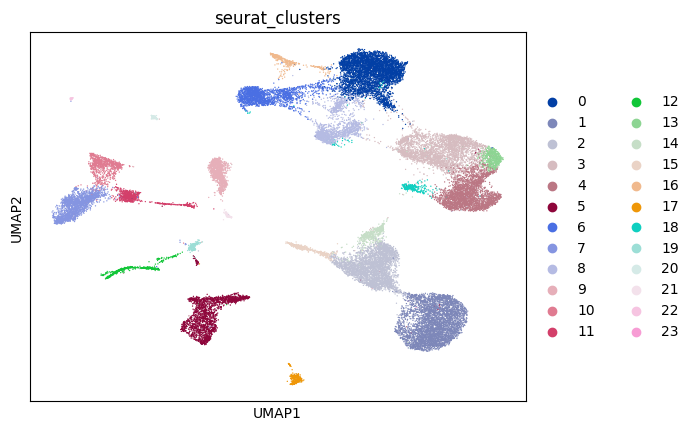

In [4]:
import pandas as pd
import numpy as np
import scanpy as sc

# Load Seurat UMAP coordinates
umap_df = pd.read_csv("/home/mth07/Documents/scRNA_project2/scripts/GSE183276_umap_coordinates.csv", index_col=0)

# Sanity check
print(umap_df.shape) 

# Inject into AnnData
GSE183276_harmony_adata.obsm['X_umap'] = umap_df.loc[GSE183276_harmony_adata.obs_names].values
sc.pl.umap(GSE183276_harmony_adata, color='seurat_clusters', show=True)

In [5]:
# Put log-normalized counts into X (only for CellTypist)
GSE183276_harmony_adata.X = GSE183276_harmony_adata.layers['logcounts'].copy()

In [6]:
import celltypist
from celltypist import models

ct_pred = celltypist.annotate(GSE183276_harmony_adata, model="/home/mth07/Documents/scRNA_project2/scripts/Adult_Human_Kidney.pkl", majority_voting=True)

🔬 Input data has 32251 cells and 16545 genes
🔗 Matching reference genes in the model
🧬 9172 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


In [7]:
GSE183276_harmony_adata.obs['majority_voting'] = (ct_pred.predicted_labels['majority_voting'].astype(str))

In [8]:
print(GSE183276_harmony_adata.obs['majority_voting'].value_counts().head())

majority_voting
aPT      5720
PT       3879
PC       3838
aTAL     3451
C-TAL    2447
Name: count, dtype: int64


... storing 'majority_voting' as categorical


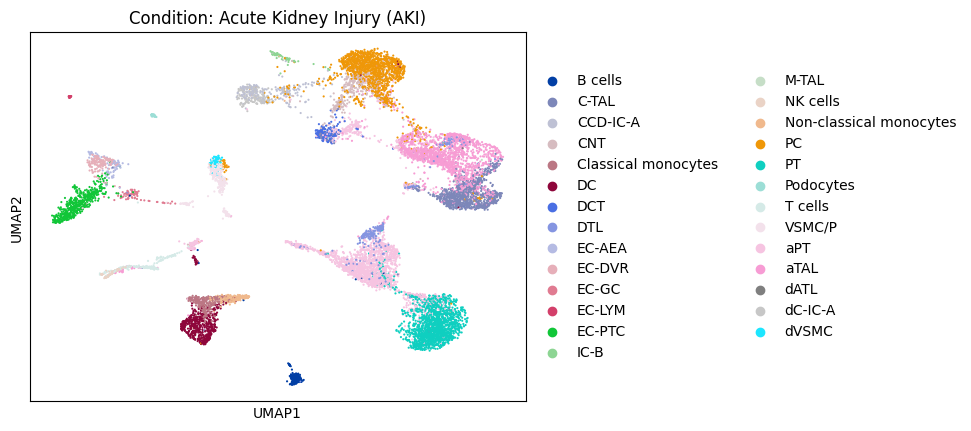

... storing 'majority_voting' as categorical


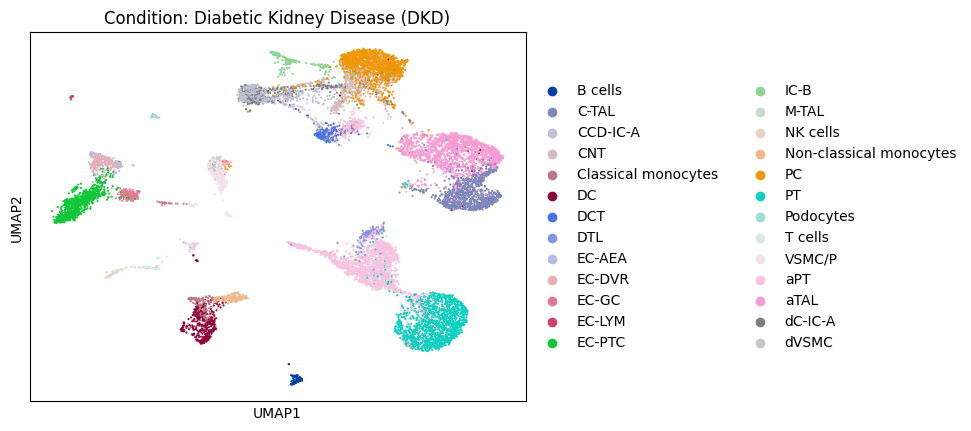

... storing 'majority_voting' as categorical


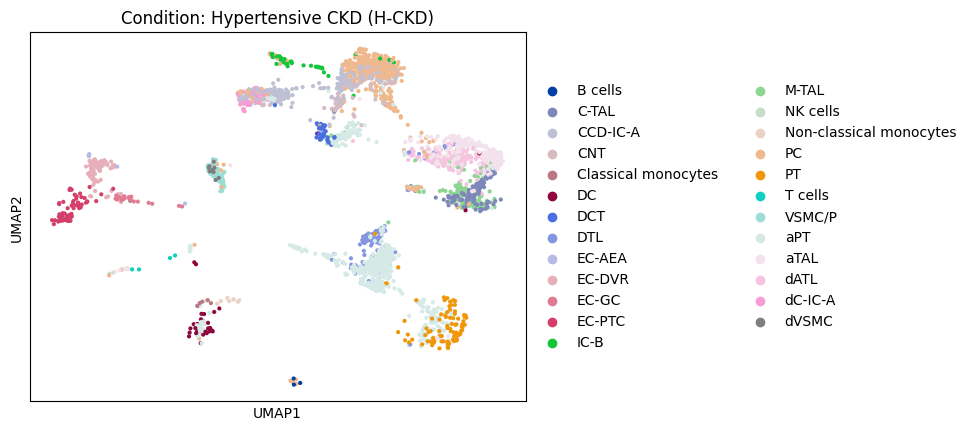

... storing 'majority_voting' as categorical


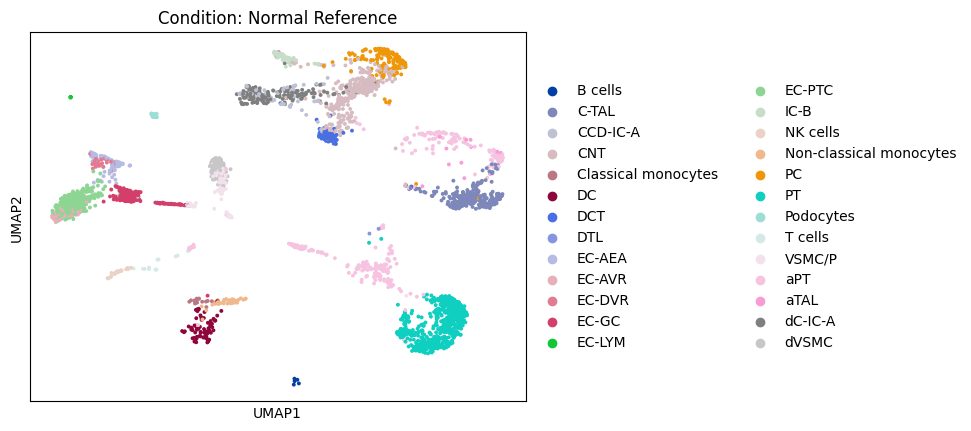

In [9]:
import matplotlib.pyplot as plt

for cond in GSE183276_harmony_adata.obs['Condition'].unique():
    fig = sc.pl.umap(GSE183276_harmony_adata[GSE183276_harmony_adata.obs['Condition'] == cond],
        color='majority_voting',title=f'Condition: {cond}',legend_loc='right margin',show=False,return_fig=True)
    plt.savefig(f"/home/mth07/Documents/scRNA_project2/scripts/plots/ct_{cond}.png",dpi=300,bbox_inches='tight')
    plt.show()

In [10]:
import celltypist
from celltypist import models

# Put log-normalized counts into X (only for CellTypist)
GSE183276_raw_adata.X = GSE183276_raw_adata.layers['logcounts'].copy()
ct_pred = celltypist.annotate(GSE183276_raw_adata, model="/home/mth07/Documents/scRNA_project2/scripts/Adult_Human_Kidney.pkl", majority_voting=True)

🔬 Input data has 32251 cells and 16545 genes
🔗 Matching reference genes in the model
🧬 9172 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


In [11]:
GSE183276_raw_adata.obs['majority_voting'] = (ct_pred.predicted_labels['majority_voting'].astype(str))

In [12]:
print(GSE183276_raw_adata.obs.columns.tolist())

['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rb', 'sample', 'Condition', 'mahal_dist_nCount', 'pca_clusters', 'ident', 'majority_voting']


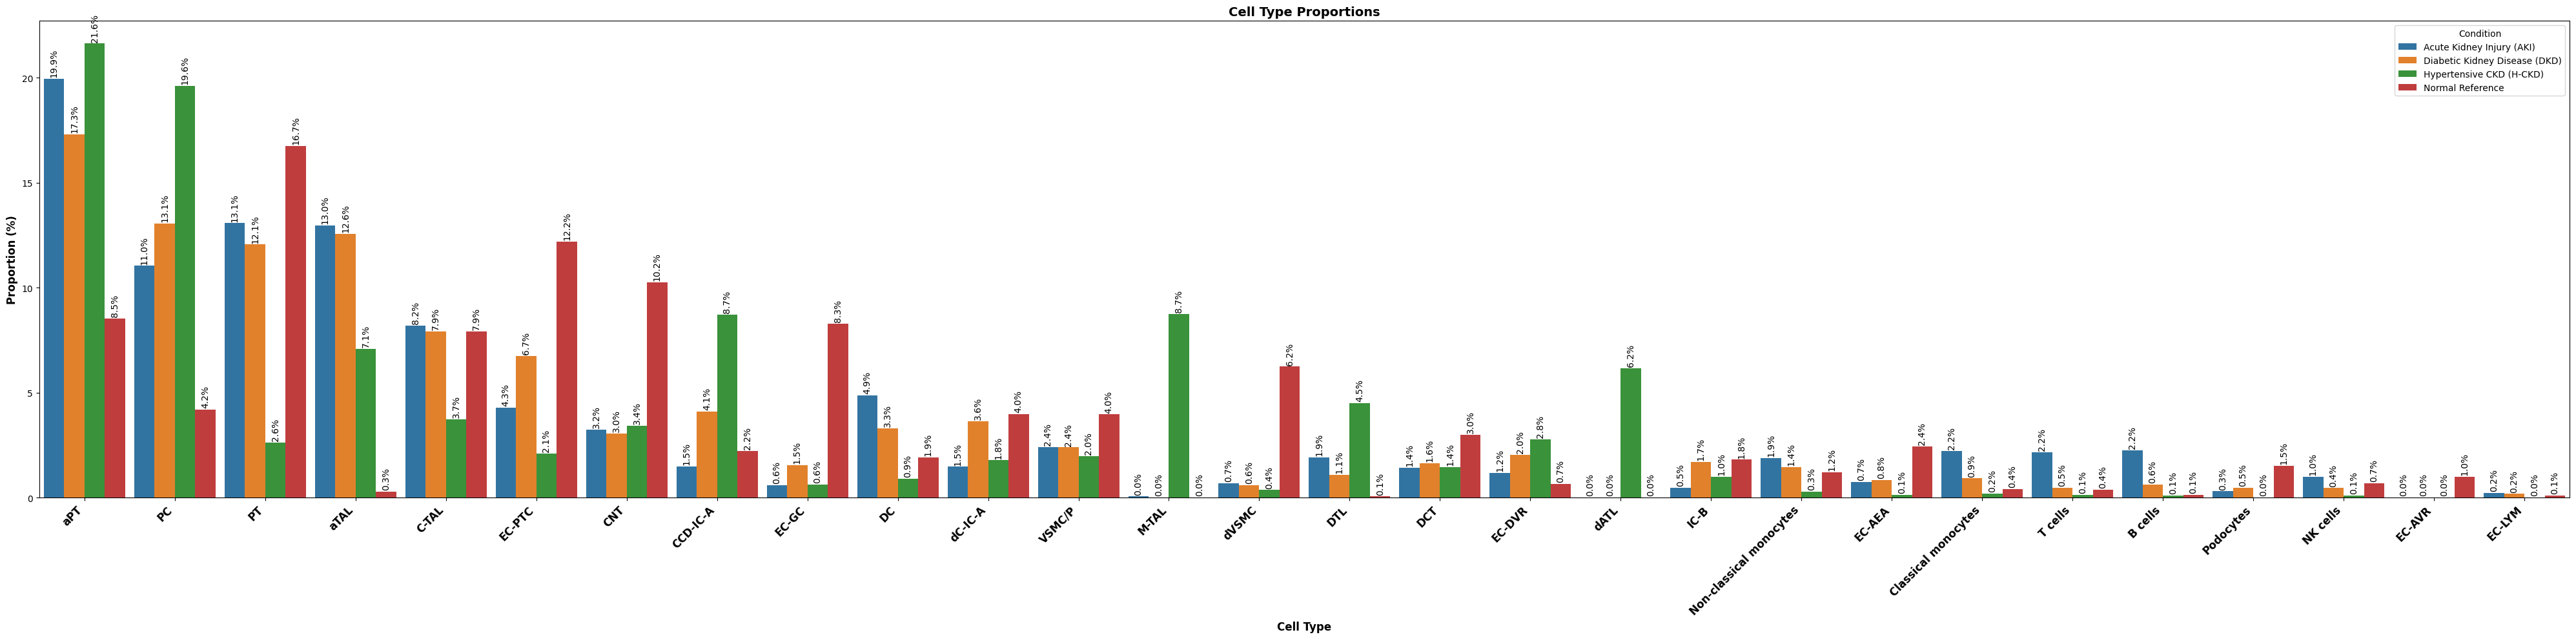

In [13]:
# Step 1: Count cells per cell type per condition
n_cells_condition = (GSE183276_raw_adata.obs.groupby(["Condition", "majority_voting"]).size().reset_index(name="count"))

# Step 2: Calculate proportions per condition
n_cells_condition["total"] = n_cells_condition.groupby("Condition")["count"].transform("sum")
n_cells_condition["proportion"] = (n_cells_condition["count"] / n_cells_condition["total"]) * 100

# Step 3: Compute average proportion per cell type for ordering
avg_proportions = (n_cells_condition.groupby("majority_voting")["proportion"].mean().sort_values(ascending=False))
ordered_celltypes = avg_proportions.index.tolist()

# Step 4: Plot
plt.figure(figsize=(40, 10))
ax = sns.barplot(
    data=n_cells_condition,
    x="majority_voting",
    y="proportion",
    hue="Condition",
    order=ordered_celltypes,
    dodge=True,
    width=0.9
)

# Step 5: Add proportion labels
for container in ax.containers:ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2, fontsize=10, rotation = 90)

# Customize axes
plt.xticks(rotation=45, ha="right", fontsize=12, fontweight="bold")
plt.ylabel("Proportion (%)", fontsize=12, fontweight="bold")
plt.xlabel("Cell Type", fontsize=12, fontweight="bold")
plt.title("Cell Type Proportions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/home/mth07/Documents/scRNA_project/scripts/plots/cellproportions_barplot.png", dpi=300, bbox_inches='tight')
plt.show()

n_cells_condition.to_csv("/home/mth07/Documents/scRNA_project2/scripts/output/Cellproportions.csv", index=False)

In [14]:
# Create combined group label FIRST
GSE183276_raw_adata.obs['majority_voting'] = (GSE183276_raw_adata.obs['majority_voting'].astype(str)
    + "_" +
    GSE183276_raw_adata.obs['Condition'].astype(str)
)

In [15]:
def find_unique_markers(
    adata, 
    groupby='cell_type', 
    method='wilcoxon', 
    pval_threshold=0.05, 
    logfc_threshold=0.25,
    top_n=3,
    min_cells_per_group=2
):
    """
    Mimics Seurat's FindAllMarkers + filters for unique DEGs per cluster.
    
    Parameters:
        adata : AnnData object
        groupby : column in adata.obs to group cells (e.g., clusters, cell_type)
        method : DEG test method ('wilcoxon', 't-test', 'logreg')
        pval_threshold : adjusted p-value threshold for significance
        logfc_threshold : log fold change threshold for filtering

    Returns:
        unique_degs_df : DataFrame of DEGs unique to each group
    """

    # Filter out low-cell groups
    group_counts = adata.obs[groupby].value_counts()
    valid_groups = group_counts[group_counts >= min_cells_per_group].index.tolist()

    # Subset AnnData to valid groups only
    adata_filtered = adata[adata.obs[groupby].isin(valid_groups)].copy()
    
    # Run DEG analysis
    sc.tl.rank_genes_groups(adata_filtered, groupby=groupby, method=method)
    
    # Get full results into a DataFrame
    all_degs = sc.get.rank_genes_groups_df(adata_filtered, group=None)
    
    # Filter by significance
    filtered_degs = all_degs[
        (all_degs['pvals_adj'] < pval_threshold) &
        (abs(all_degs['logfoldchanges']) > logfc_threshold)
    ]

    # Find genes that appear in only one group
    unique_genes = (
        filtered_degs.groupby('names')['group']
        .nunique()
        .reset_index()
        .query('group == 1')['names']
        .tolist()
    )

    # Keep only unique DEGs
    unique_degs_df = filtered_degs[filtered_degs['names'].isin(unique_genes)].copy()


    # Select top N per group by logFC
    top_unique_degs_df = (
        unique_degs_df
        .sort_values(['group', 'logfoldchanges'], ascending=[True, False])
        .groupby('group')
        .head(top_n)
        .reset_index(drop=True)
    )

    return top_unique_degs_df

In [17]:
unique_markers = find_unique_markers(GSE183276_raw_adata, groupby='majority_voting', method='wilcoxon', pval_threshold=0.05, logfc_threshold=0.25,
top_n=3, min_cells_per_group=4)

unique_markers['group'] = (
    unique_markers['group']
    .str.replace(
        r'_(Acute Kidney Injury|Diabetic Kidney Disease|Hypertensive CKD|Normal Reference)_\1$',
        r'_\1',
        regex=True
    )
)

# Inspect & save
print(unique_markers.head())
unique_markers['group'].drop_duplicates()

unique_markers.to_csv("/home/mth07/Documents/scRNA_project2/scripts/output/Unique_cluster_markers.csv", index=False)

... storing 'majority_voting' as categorical


                                   group    names    scores  logfoldchanges  \
0      B cells_Acute Kidney Injury (AKI)     LAX1  4.584188        7.377149   
1      B cells_Acute Kidney Injury (AKI)    IGLL5  4.376475        7.306941   
2      B cells_Acute Kidney Injury (AKI)  PKHD1L1  5.894721        7.166197   
3  B cells_Diabetic Kidney Disease (DKD)    AMPD1  3.733907        8.754725   
4        C-TAL_Acute Kidney Injury (AKI)    PRODH  7.256159        4.928203   

          pvals     pvals_adj  
0  4.557551e-06  4.651738e-05  
1  1.206142e-05  1.148856e-04  
2  3.753149e-09  6.160303e-08  
3  1.885324e-04  4.320316e-03  
4  3.982359e-13  9.359109e-12  


... storing 'majority_voting' as categorical


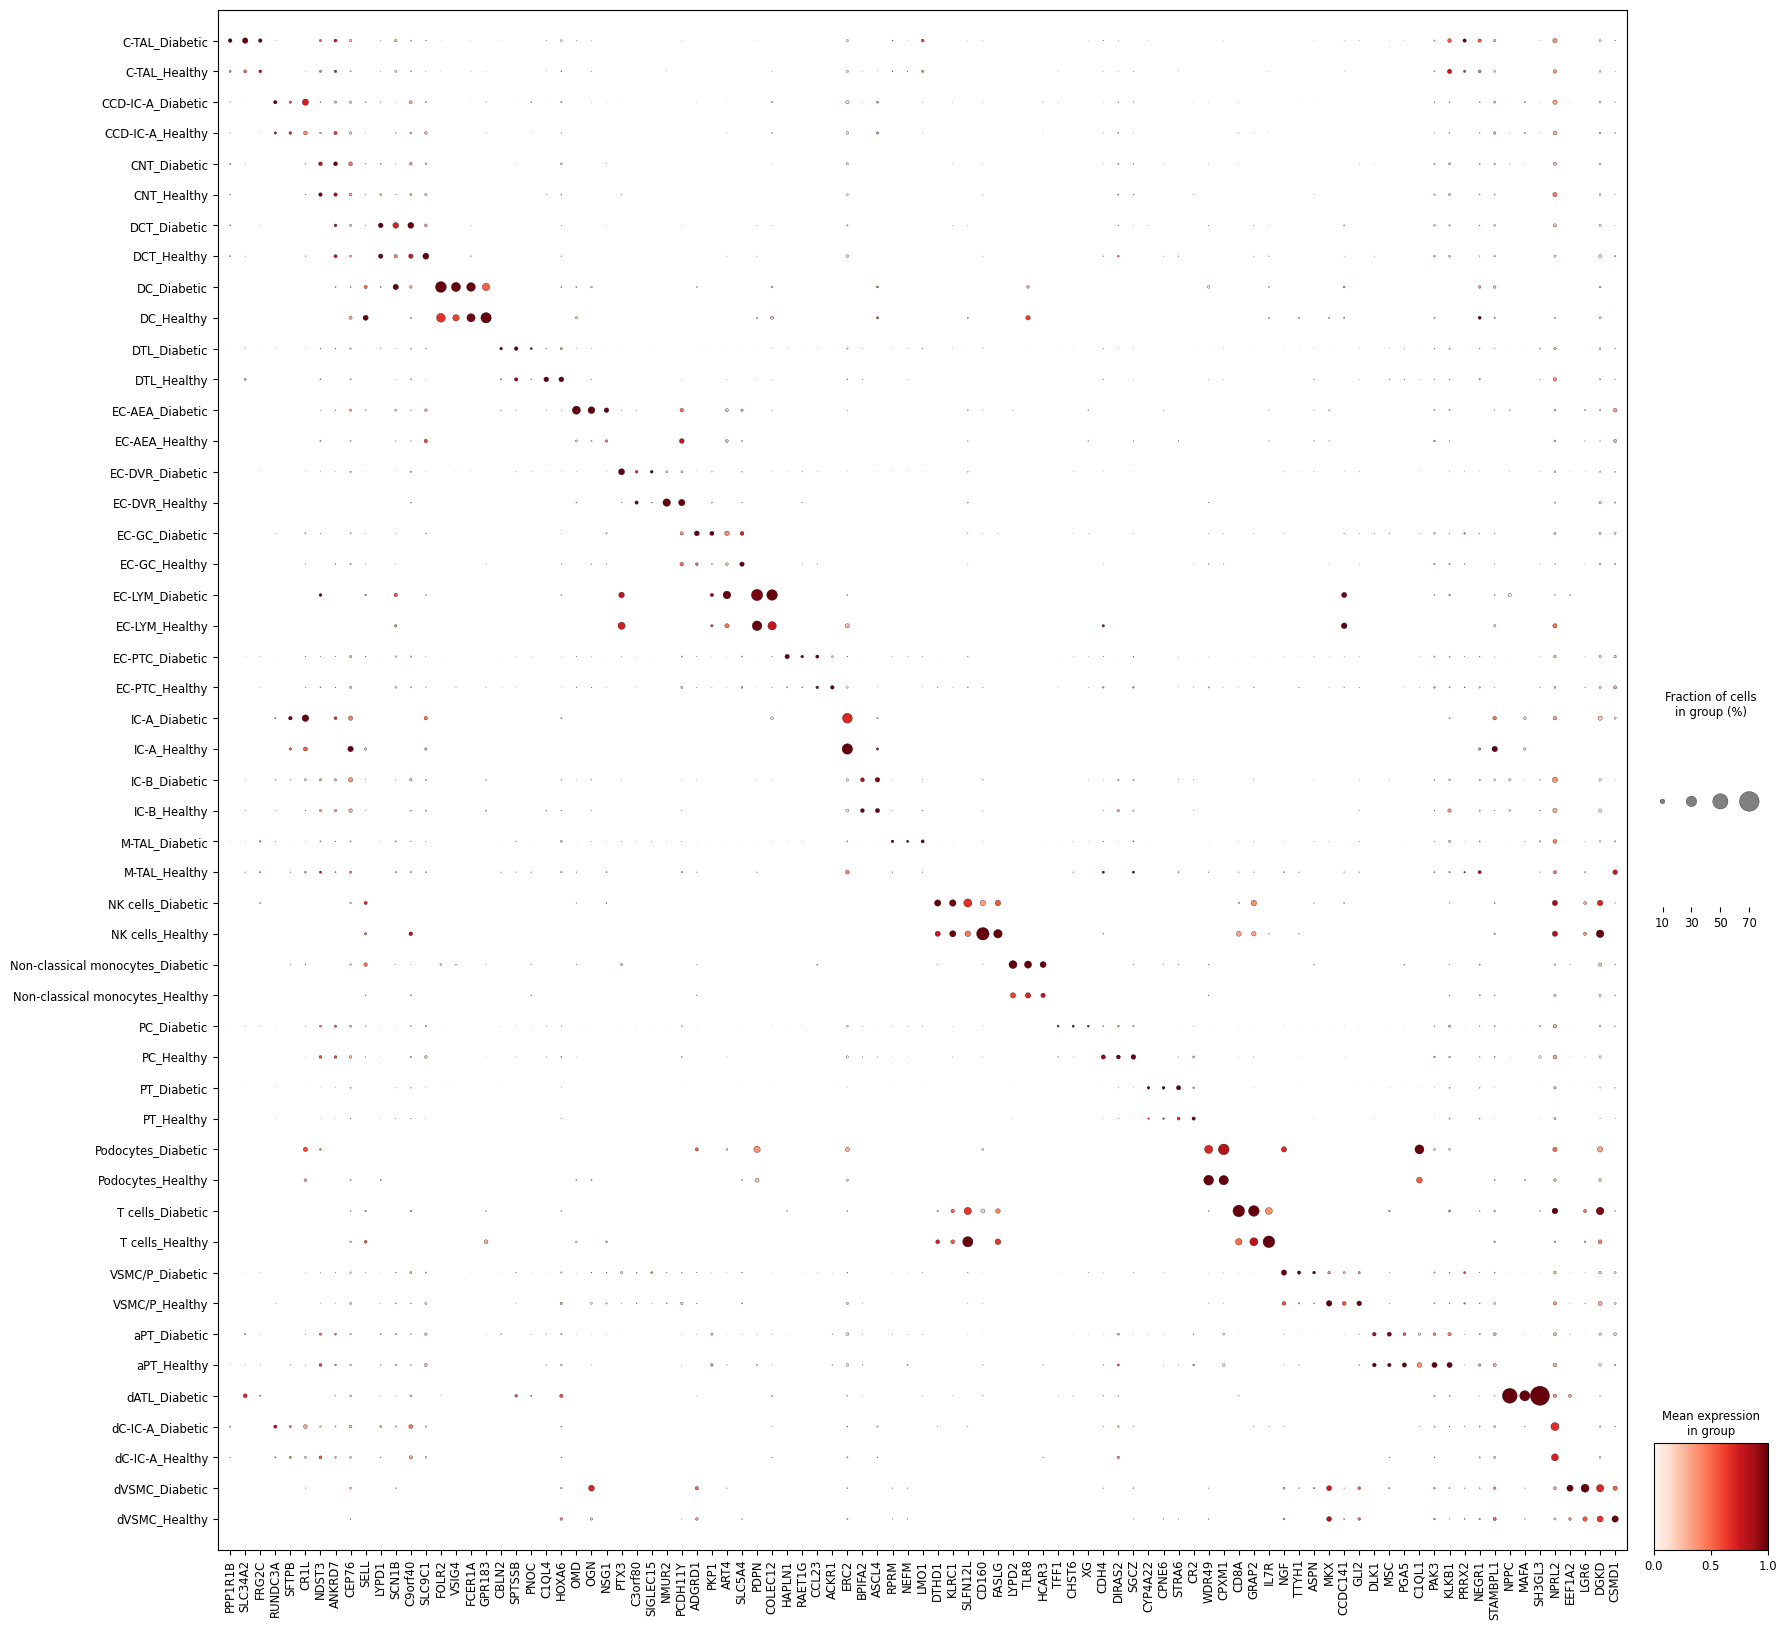

In [36]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

excluded_prefixes = ["Classical monocytes"]
mask = ~GSE183276_raw_adata.obs['majority_voting'].str.startswith(tuple(excluded_prefixes))
adata_to_plot = GSE183276_raw_adata[mask].copy()

genes_to_plot = unique_markers["names"].tolist()  

genes_to_plot = [g for g in genes_to_plot if g in adata_to_plot.var_names]

X = adata_to_plot[:, genes_to_plot].X
if hasattr(X, "toarray"):  # sparse -> dense
    X = X.toarray()

# Make a DataFrame: rows = cell types, columns = genes
expr_df = pd.DataFrame(X, index=adata_to_plot.obs['majority_voting'], columns=genes_to_plot)

expr_per_group = expr_df.groupby(expr_df.index).sum()  # rows = groups, columns = genes

# Keep only genes where max across groups ≥ 30
genes_filtered = expr_per_group.columns[(expr_per_group.max(axis=0) >= 30)].tolist()

# Filter expression DataFrame
expr_per_group = expr_per_group[genes_filtered]

valid_groups = expr_per_group.index[(expr_per_group.sum(axis=1) > 20)].tolist()
adata_to_plot = adata_to_plot[adata_to_plot.obs['majority_voting'].isin(valid_groups)].copy()

sc.pl.dotplot(adata_to_plot, var_names=genes_filtered, groupby='majority_voting', standard_scale='var', show=False, figsize=(20, 20),
    dendrogram=False)
plt.savefig("/home/mth07/Documents/scRNA_project2/scripts/plots/Cluster_Markergenes.png", dpi=300, bbox_inches='tight')
plt.show()

In [37]:
GSE183276_raw_adata.write("/home/mth07/Documents/scRNA_project2/scripts/output/GSE183276_celltypist.h5ad")

... storing 'majority_voting' as categorical
